# 03 — Sales Forecasting: Baseline Models + Prophet

**Goal:** Build a forecasting pipeline that projects monthly revenue by product line and country, with proper baselines and walk-forward backtesting. This is the first model attempting to answer the VP Merchandising's question:

> *"How much will we sell next quarter and next year, by product line and region, so we can plan inventory and staffing accordingly?"*

**What this notebook does:**
1. Aggregate `fact_sales` to monthly revenue by `product_line x country` (up to 24 series)
2. Drop January 2014 — known to be incomplete (bike sales missing)
3. Filter series to those with at least 18 months of history (forecasting needs seasonality data)
4. Build two **baselines** that any "real" model must beat:
   - Naive: forecast = last observed value
   - Seasonal naive: forecast = value from 12 months ago
5. Fit **Prophet** with yearly seasonality on each remaining series
6. Walk-forward backtest on the last 6 months — train on everything before, predict ahead
7. Evaluate with MAPE, MAE, RMSE per series
8. Visualize forecasts vs actuals
9. **Honest comparison** — report whether Prophet beats the baselines
10. Generate a forward forecast for the next 6 months
11. Save outputs for the prescriptive notebook

**Inputs:**
- `data/processed/fact_sales.csv`
- `data/processed/dim_customers.csv`
- `data/processed/dim_products.csv`

**Outputs:**
- `data/predictions/forecasts.csv` — forecasted revenue per `product_line x country x month` with confidence intervals
- `data/predictions/forecast_evaluation.csv` — backtest metrics per series

**A note on data scale:** This dataset has only ~37 months of history. That's marginal for Prophet — typical guidance is 2-3 full seasonal cycles, and we have just under 3. With more data, Prophet would shine. With this volume, expect baselines to be competitive.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import io
import sys
import logging

from prophet import Prophet

# Quiet noisy logs
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titleweight'] = 'bold'

DATA_DIR = Path('../data/processed')
PRED_DIR = Path('../data/predictions')
PRED_DIR.mkdir(parents=True, exist_ok=True)

TEST_MONTHS = 6       # walk-forward evaluation window
HORIZON_MONTHS = 6    # forward forecast horizon
MIN_HISTORY = 18      # minimum months of history to model a series

print(f'Data dir:        {DATA_DIR.resolve()}')
print(f'Predictions dir: {PRED_DIR.resolve()}')
print(f'Test window:     last {TEST_MONTHS} months')
print(f'Forward horizon: {HORIZON_MONTHS} months')


Importing plotly failed. Interactive plots will not work.


Data dir:        /home/claude/phase3/data/processed
Predictions dir: /home/claude/phase3/data/predictions
Test window:     last 6 months
Forward horizon: 6 months


## 2. Build the Monthly Series

In [2]:
fact = pd.read_csv(DATA_DIR / 'fact_sales.csv', parse_dates=['order_date'])
cust = pd.read_csv(DATA_DIR / 'dim_customers.csv')
prod = pd.read_csv(DATA_DIR / 'dim_products.csv')

# Drop null-date transactions (small handful, see EDA notebook)
n_before = len(fact)
fact = fact.dropna(subset=['order_date'])
print(f'Dropped {n_before - len(fact)} rows with null order_date')

# Enrich fact with product line and country
fact = (fact.merge(cust[['customer_key', 'country']], on='customer_key', how='left')
            .merge(prod[['product_key', 'product_line']], on='product_key', how='left'))

print(f'fact rows: {len(fact):,}')
print(f'Date range: {fact["order_date"].min().date()} to {fact["order_date"].max().date()}')


Dropped 19 rows with null order_date
fact rows: 60,379
Date range: 2010-12-29 to 2014-01-28


### Drop incomplete months

January 2014 shows transaction counts but very low revenue ($46K vs $1.5M+ in surrounding months). On inspection, only accessory sales are present — bike sales are missing entirely from that month's data. Most likely a partial load. We exclude it from training and evaluation.


In [3]:
# Diagnose: revenue by month
monthly_revenue = (
    fact.assign(month=fact['order_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month')['sales_amount']
    .sum()
)
print('Last 6 months of revenue:')
print(monthly_revenue.tail(6))
print(f'\nJanuary 2014 vs. average of Oct-Dec 2013: {monthly_revenue.iloc[-1] / monthly_revenue.iloc[-4:-1].mean():.1%}')


Last 6 months of revenue:
month
2013-08-01    1545910
2013-09-01    1447324
2013-10-01    1673261
2013-11-01    1780688
2013-12-01    1874128
2014-01-01      45642
Name: sales_amount, dtype: int64

January 2014 vs. average of Oct-Dec 2013: 2.6%


In [4]:
# Drop January 2014 from training data
fact = fact[fact['order_date'] < '2014-01-01']
print(f'Rows after dropping Jan 2014: {len(fact):,}')
print(f'New date range: {fact["order_date"].min().date()} to {fact["order_date"].max().date()}')


Rows after dropping Jan 2014: 58,409
New date range: 2010-12-29 to 2013-12-31


In [5]:
# Aggregate to monthly revenue by product_line x country
monthly = (
    fact.assign(month=fact['order_date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['product_line', 'country', 'month'])
    .agg(revenue=('sales_amount', 'sum'))
    .reset_index()
)
print(f'Total monthly observations: {len(monthly):,}')
print()
print(monthly.head(10))


Total monthly observations: 588

  product_line    country      month  revenue
0     Mountain  Australia 2010-12-01    10175
1     Mountain  Australia 2011-01-01    57625
2     Mountain  Australia 2011-02-01    57525
3     Mountain  Australia 2011-03-01    13575
4     Mountain  Australia 2011-04-01    50775
5     Mountain  Australia 2011-05-01    60975
6     Mountain  Australia 2011-06-01    54100
7     Mountain  Australia 2011-07-01    64350
8     Mountain  Australia 2011-08-01    16950
9     Mountain  Australia 2011-09-01    64375


### Profile the series

In [6]:
series_lengths = (
    monthly.groupby(['product_line', 'country'])
    .agg(months=('month', 'count'),
         total_revenue=('revenue', 'sum'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
series_lengths['modellable'] = series_lengths['months'] >= MIN_HISTORY

print(f'Total series:    {len(series_lengths)}')
print(f'Modellable (>= {MIN_HISTORY} months): {series_lengths["modellable"].sum()}')
print(f'Too short:       {(~series_lengths["modellable"]).sum()}')
print()
print(series_lengths)


Total series:    24
Modellable (>= 18 months): 12
Too short:       12

   product_line         country  months  total_revenue  modellable
12         Road       Australia      37        5027759        True
17         Road   United States      37        4107853        True
5      Mountain   United States      37        3538953        True
0      Mountain       Australia      37        2904111        True
16         Road  United Kingdom      37        1609712        True
15         Road         Germany      36        1389450        True
14         Road          France      36        1322735        True
23      Touring   United States      13        1301687       False
4      Mountain  United Kingdom      36        1182114        True
3      Mountain         Germany      33        1020431        True
18      Touring       Australia      13         997419       False
13         Road          Canada      37         947826        True
2      Mountain          France      35         914149    

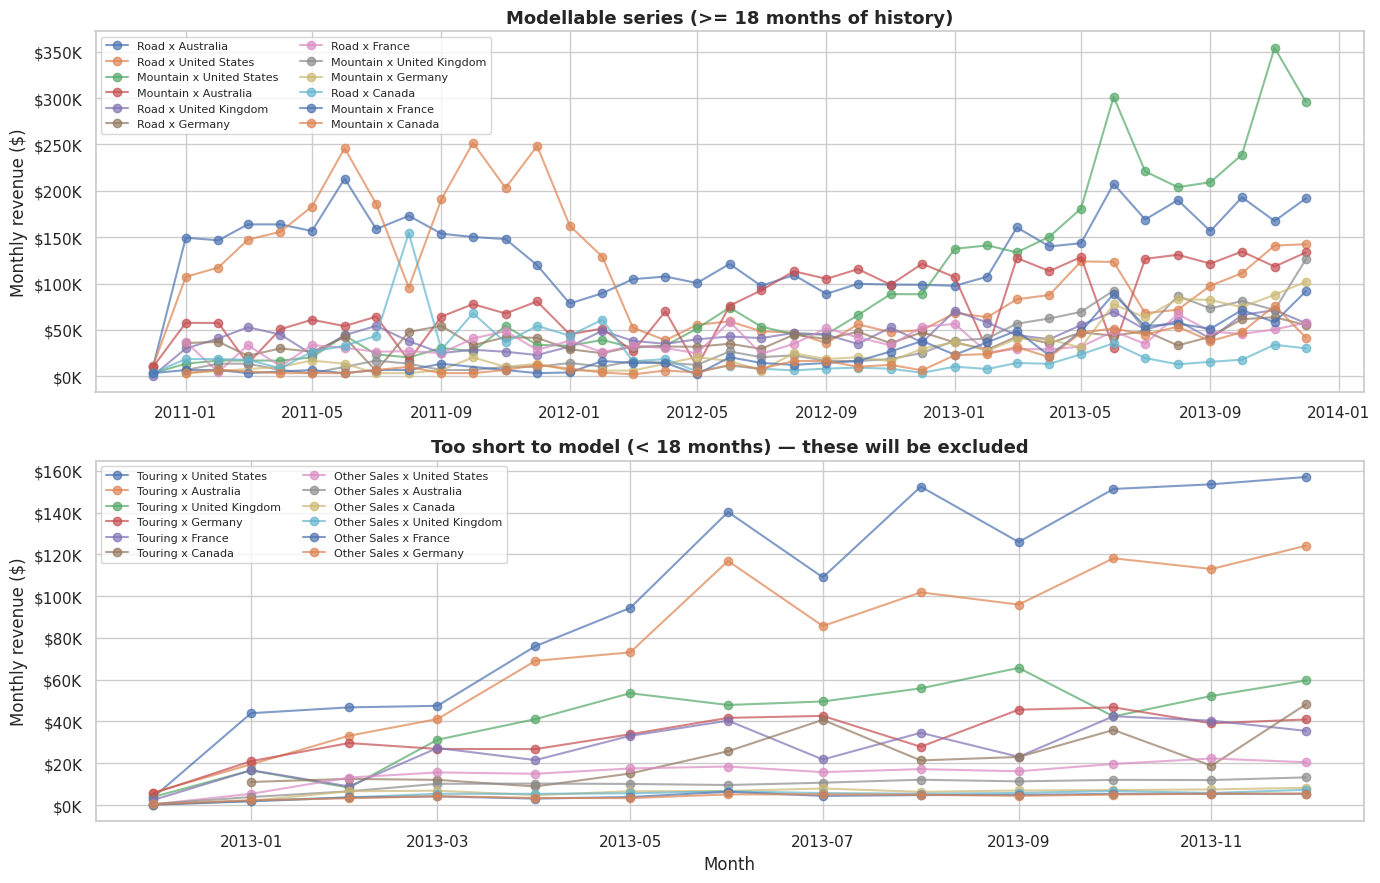

In [7]:
# Visualize all series — modellable vs too short
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for _, row in series_lengths.iterrows():
    series = monthly[(monthly['product_line'] == row['product_line']) &
                     (monthly['country'] == row['country'])]
    label = f'{row["product_line"]} x {row["country"]}'
    if row['modellable']:
        axes[0].plot(series['month'], series['revenue'], marker='o', label=label, alpha=0.7)
    else:
        axes[1].plot(series['month'], series['revenue'], marker='o', label=label, alpha=0.7)

axes[0].set_title(f'Modellable series (>= {MIN_HISTORY} months of history)', fontsize=13)
axes[0].set_ylabel('Monthly revenue ($)')
axes[0].legend(loc='upper left', fontsize=8, ncol=2)
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e3:.0f}K'))

axes[1].set_title(f'Too short to model (< {MIN_HISTORY} months) — these will be excluded', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Monthly revenue ($)')
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()


## 3. Walk-Forward Backtest — Baselines + Prophet

For each modellable series, we:
1. Hold out the **last 6 months** as the test set
2. Train Prophet (and compute baselines) on everything before
3. Predict the held-out months
4. Compare predictions to actuals using MAPE, MAE, RMSE

**Why walk-forward and not random split?** Time series have temporal structure. A random train/test split would leak future information into the training set. Walk-forward respects that train must always precede test.


In [8]:
def evaluate_predictions(actuals, preds):
    """Compute MAPE, MAE, RMSE."""
    actuals = np.asarray(actuals)
    preds = np.asarray(preds)
    mask = actuals > 0
    if not mask.any():
        return {'MAPE': np.nan, 'MAE': np.nan, 'RMSE': np.nan}
    mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    mae = np.mean(np.abs(actuals - preds))
    rmse = np.sqrt(np.mean((actuals - preds) ** 2))
    return {'MAPE': mape, 'MAE': mae, 'RMSE': rmse}


def fit_prophet(train_df):
    """Fit Prophet quietly, returning the model."""
    m = Prophet(yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                changepoint_prior_scale=0.05)
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    try:
        m.fit(train_df)
    finally:
        sys.stdout = old_stdout
    return m

print('Helpers defined.')


Helpers defined.


In [9]:
# Run the backtest loop across all modellable series
modellable = series_lengths[series_lengths['modellable']].reset_index(drop=True)
print(f'Backtesting {len(modellable)} series...\n')

results = []
for idx, row in modellable.iterrows():
    pl, ctry = row['product_line'], row['country']
    s = monthly[(monthly['product_line']==pl) & (monthly['country']==ctry)].sort_values('month')

    if len(s) < TEST_MONTHS + 6:  # need some history before test window
        continue

    train = s.iloc[:-TEST_MONTHS]
    test = s.iloc[-TEST_MONTHS:]
    actuals = test['revenue'].values

    # Naive: forecast = last training value
    naive_pred = np.full(TEST_MONTHS, train['revenue'].iloc[-1])
    naive_metrics = evaluate_predictions(actuals, naive_pred)

    # Seasonal naive: forecast = 12 months ago (if we have 12+ months of training history)
    if len(train) >= 12 + TEST_MONTHS:
        sn_pred = s.iloc[-TEST_MONTHS-12:-12]['revenue'].values
    elif len(train) >= 12:
        sn_pred = np.full(TEST_MONTHS, train['revenue'].iloc[-12])
    else:
        sn_pred = naive_pred
    sn_metrics = evaluate_predictions(actuals, sn_pred)

    # Prophet
    prophet_df = train.rename(columns={'month':'ds', 'revenue':'y'})[['ds','y']]
    m = fit_prophet(prophet_df)
    future = m.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
    forecast = m.predict(future)
    prophet_pred = forecast.iloc[-TEST_MONTHS:]['yhat'].values
    prophet_metrics = evaluate_predictions(actuals, prophet_pred)

    for model_name, metrics, preds in [
        ('Naive', naive_metrics, naive_pred),
        ('SeasonalNaive', sn_metrics, sn_pred),
        ('Prophet', prophet_metrics, prophet_pred)
    ]:
        results.append({
            'product_line': pl, 'country': ctry, 'model': model_name,
            'months_train': len(train), 'months_test': TEST_MONTHS,
            **metrics
        })

    print(f'  [{idx+1}/{len(modellable)}] {pl} x {ctry}: '
          f'Naive {naive_metrics["MAPE"]:.0f}%  '
          f'SeasonalNaive {sn_metrics["MAPE"]:.0f}%  '
          f'Prophet {prophet_metrics["MAPE"]:.0f}%')

results_df = pd.DataFrame(results)
print('\nBacktest complete.')


Backtesting 12 series...



22:40:50 - cmdstanpy - INFO - Chain [1] start processing


22:40:50 - cmdstanpy - INFO - Chain [1] done processing


22:40:50 - cmdstanpy - INFO - Chain [1] start processing


22:40:50 - cmdstanpy - INFO - Chain [1] done processing


...

22:40:52 - cmdstanpy - INFO - Chain [1] done processing


  [10/12] Road x Canada: Naive 84%  SeasonalNaive 61%  Prophet 93%


22:40:52 - cmdstanpy - INFO - Chain [1] start processing


22:40:52 - cmdstanpy - INFO - Chain [1] done processing


  [11/12] Mountain x France: Naive 46%  SeasonalNaive 69%  Prophet 27%
  [12/12] Mountain x Canada: Naive 20%  SeasonalNaive 76%  Prophet 42%

Backtest complete.


## 4. Compare Models

In [10]:
# Aggregate metrics by model
summary = (
    results_df.groupby('model')
    .agg(median_MAPE=('MAPE', 'median'),
         mean_MAPE=('MAPE', 'mean'),
         median_MAE=('MAE', 'median'),
         median_RMSE=('RMSE', 'median'),
         series=('product_line', 'count'))
    .round(1)
    .sort_values('median_MAPE')
)
print('Overall model comparison (lower is better):')
print(summary)


Overall model comparison (lower is better):
               median_MAPE  mean_MAPE  median_MAE  median_RMSE  series
model                                                                 
Naive                 27.3       34.5     18092.3      20760.0      12
Prophet               39.1       38.7     20563.8      24812.9      12
SeasonalNaive         56.2       51.6     41056.8      42476.8      12


In [11]:
# Head-to-head: how often does each model win?
pivot = results_df.pivot_table(index=['product_line', 'country'], columns='model', values='MAPE')
pivot['winner'] = pivot.idxmin(axis=1)
print('\nWinner per series (lowest MAPE):')
print(pivot['winner'].value_counts())
print()
print(pivot.round(1))



Winner per series (lowest MAPE):
winner
Naive            7
Prophet          4
SeasonalNaive    1
Name: count, dtype: int64

model                        Naive  Prophet  SeasonalNaive         winner
product_line country                                                     
Mountain     Australia        76.3      4.4           15.6        Prophet
             Canada           19.8     41.5           75.7          Naive
             France           45.5     27.3           68.9        Prophet
             Germany          12.4     55.7           77.1          Naive
             United Kingdom   31.6     36.9           74.0          Naive
             United States    28.6     41.2           74.9          Naive
Road         Australia        17.3     43.0           44.3          Naive
             Canada           84.1     93.1           61.2  SeasonalNaive
             France           15.6     14.8           22.6        Prophet
             Germany          20.9     29.7           26.6   

### Honest interpretation

If Prophet's median MAPE is materially lower than the baselines, that's a real signal — Prophet learned something the baselines couldn't. If it's similar or worse, the takeaway is **"with this data volume, a naive baseline is hard to beat."** Both outcomes are publishable.


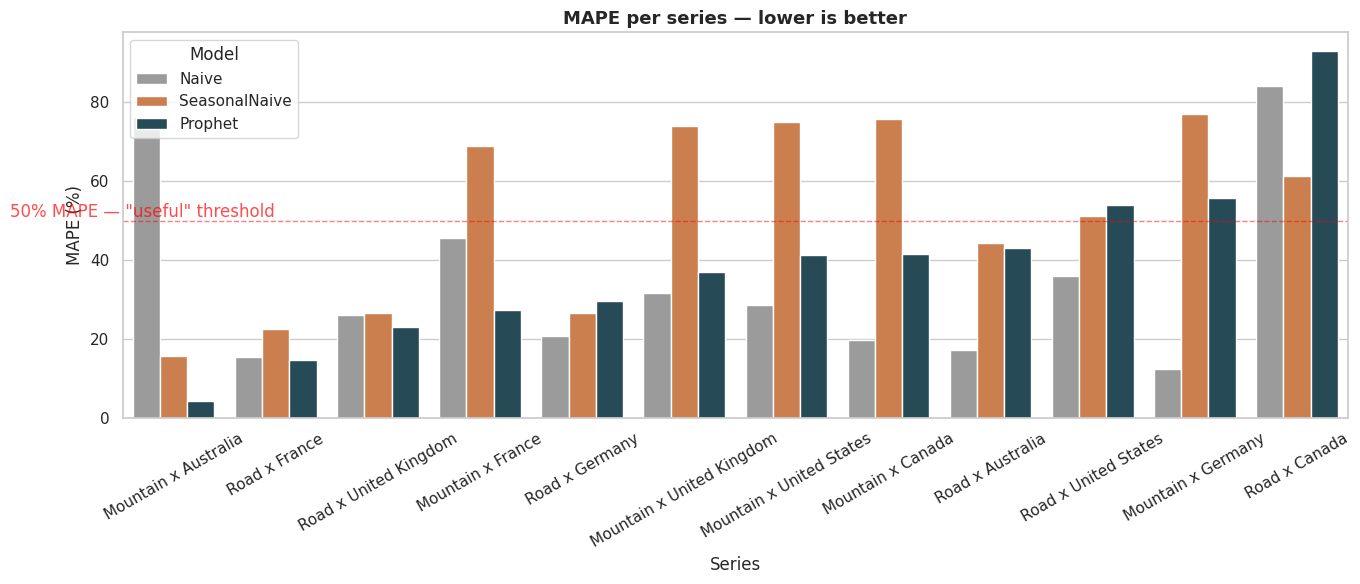

In [12]:
# Visualize: MAPE per series, grouped by model
fig, ax = plt.subplots(figsize=(14, 6))

for_plot = results_df.copy()
for_plot['series_id'] = for_plot['product_line'] + ' x ' + for_plot['country']
order = pivot.sort_values('Prophet').index.tolist()
for_plot['series_id'] = pd.Categorical(
    for_plot['series_id'],
    categories=[f'{a} x {b}' for a, b in order],
    ordered=True
)

palette = {'Naive': '#9B9B9B', 'SeasonalNaive': '#E07B39', 'Prophet': '#1F4E5F'}
sns.barplot(data=for_plot, x='series_id', y='MAPE', hue='model', palette=palette, ax=ax)
ax.set_title('MAPE per series — lower is better', fontsize=13)
ax.set_xlabel('Series')
ax.set_ylabel('MAPE (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Model')
ax.axhline(50, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.text(0.99, 50, '50% MAPE — "useful" threshold', color='red', va='bottom', ha='right', alpha=0.7)
plt.tight_layout()
plt.show()


## 5. Visualize Top Series Forecasts

22:40:53 - cmdstanpy - INFO - Chain [1] start processing


22:40:53 - cmdstanpy - INFO - Chain [1] done processing


22:40:53 - cmdstanpy - INFO - Chain [1] start processing


22:40:53 - cmdstanpy - INFO - Chain [1] done processing


22:40:53 - cmdstanpy - INFO - Chain [1] start processing


22:40:54 - cmdstanpy - INFO - Chain [1] done processing


22:40:54 - cmdstanpy - INFO - Chain [1] start processing


22:40:54 - cmdstanpy - INFO - Chain [1] done processing


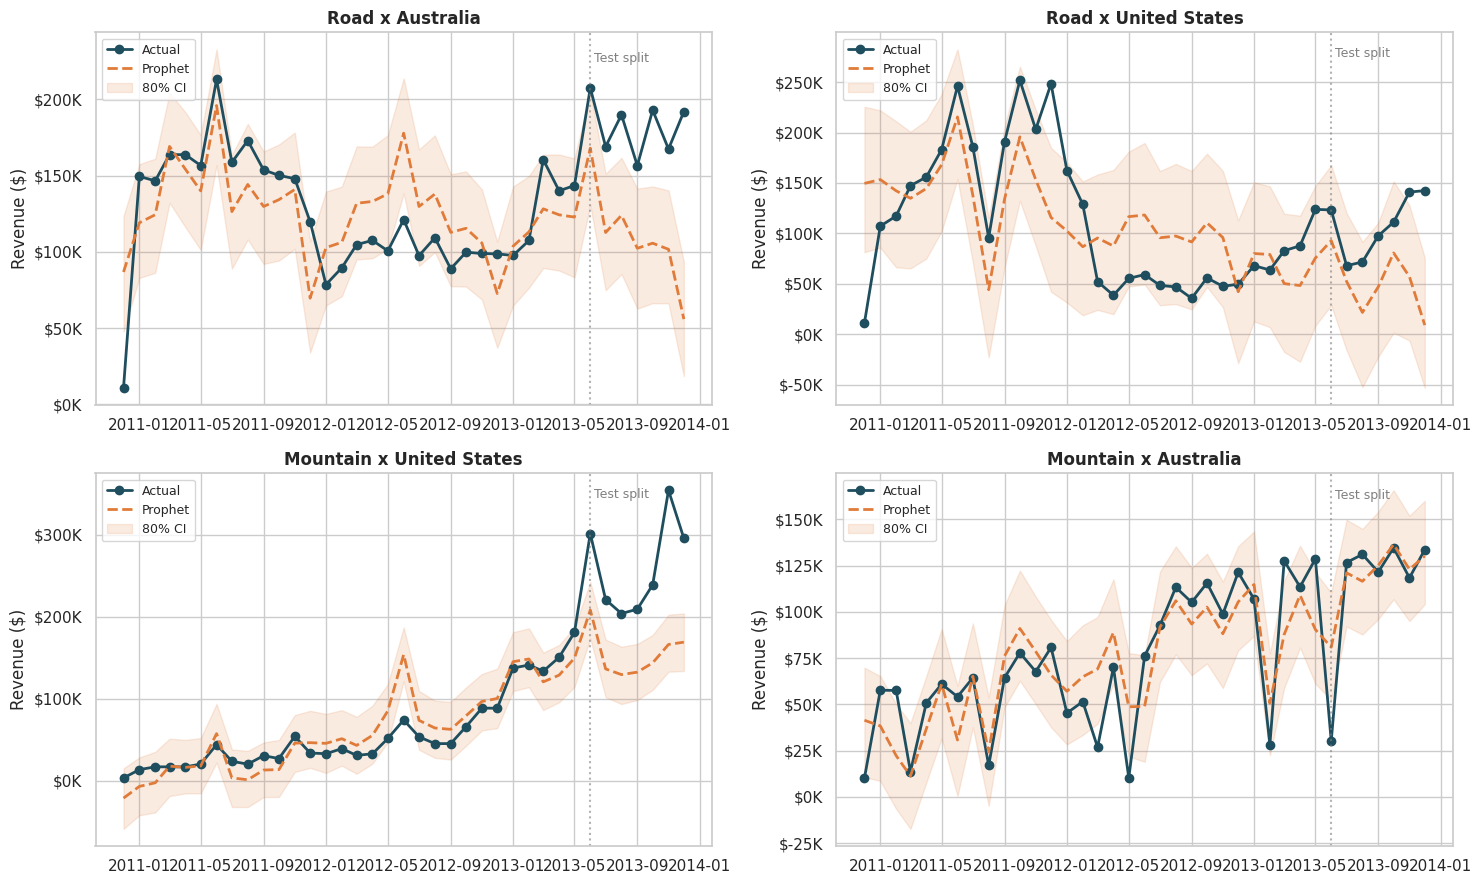

In [13]:
# Plot the Prophet forecasts for the top 4 series by revenue
top4 = series_lengths[series_lengths['modellable']].head(4)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, (_, row) in enumerate(top4.iterrows()):
    pl, ctry = row['product_line'], row['country']
    s = monthly[(monthly['product_line']==pl) & (monthly['country']==ctry)].sort_values('month').reset_index(drop=True)
    train = s.iloc[:-TEST_MONTHS]
    test = s.iloc[-TEST_MONTHS:]

    m = fit_prophet(train.rename(columns={'month':'ds','revenue':'y'})[['ds','y']])
    future = m.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
    forecast = m.predict(future)

    ax = axes[i]
    ax.plot(s['month'], s['revenue'], 'o-', color='#1F4E5F', label='Actual', linewidth=2)
    ax.plot(forecast['ds'], forecast['yhat'], '--', color='#E07B39', label='Prophet', linewidth=2)
    ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                    color='#E07B39', alpha=0.15, label='80% CI')
    ax.axvline(train['month'].iloc[-1], color='gray', linestyle=':', alpha=0.6)
    ax.text(train['month'].iloc[-1], ax.get_ylim()[1]*0.92, ' Test split',
            color='gray', fontsize=9)
    ax.set_title(f'{pl} x {ctry}', fontsize=12)
    ax.set_ylabel('Revenue ($)')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e3:.0f}K'))
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


## 6. Forward Forecast — Next 6 Months

Re-fit Prophet on the **full** history (including the test window we just evaluated on), then forecast the next 6 months. This gives stakeholders a usable projection rather than just an evaluated one.


In [14]:
print(f'Forecasting {HORIZON_MONTHS} months forward for all modellable series...')

forecasts = []
for _, row in modellable.iterrows():
    pl, ctry = row['product_line'], row['country']
    s = monthly[(monthly['product_line']==pl) & (monthly['country']==ctry)].sort_values('month')

    df = s.rename(columns={'month':'ds','revenue':'y'})[['ds','y']]
    m = fit_prophet(df)
    future = m.make_future_dataframe(periods=HORIZON_MONTHS, freq='MS')
    forecast = m.predict(future)

    # Keep only the forward-looking rows
    fwd = forecast.iloc[-HORIZON_MONTHS:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    fwd['product_line'] = pl
    fwd['country']      = ctry
    fwd['model']        = 'Prophet'
    forecasts.append(fwd)

forecasts_df = pd.concat(forecasts, ignore_index=True)
forecasts_df = forecasts_df.rename(columns={'ds':'month', 'yhat':'forecast'})
forecasts_df = forecasts_df[['product_line', 'country', 'month', 'forecast', 'yhat_lower', 'yhat_upper', 'model']]
forecasts_df['forecast'] = forecasts_df['forecast'].clip(lower=0)  # no negative sales
forecasts_df['yhat_lower'] = forecasts_df['yhat_lower'].clip(lower=0)
print(f'\nForecast rows: {len(forecasts_df)}')
print(forecasts_df.head(12))


22:40:55 - cmdstanpy - INFO - Chain [1] start processing


Forecasting 6 months forward for all modellable series...


22:40:55 - cmdstanpy - INFO - Chain [1] done processing


22:40:55 - cmdstanpy - INFO - Chain [1] start processing


22:40:55 - cmdstanpy - INFO - Chain [1] done processing


...

22:40:57 - cmdstanpy - INFO - Chain [1] start processing


22:40:58 - cmdstanpy - INFO - Chain [1] done processing


22:40:58 - cmdstanpy - INFO - Chain [1] start processing


22:40:58 - cmdstanpy - INFO - Chain [1] done processing



Forecast rows: 72
   product_line        country      month       forecast     yhat_lower     yhat_upper    model
0          Road      Australia 2014-01-01  124380.317962   77842.084411  169335.063589  Prophet
1          Road      Australia 2014-02-01  133509.902111   88939.059701  179014.013888  Prophet
2          Road      Australia 2014-03-01  163418.849575  119157.185230  209556.962925  Prophet
3          Road      Australia 2014-04-01  154285.334359  110898.773257  199972.218187  Prophet
4          Road      Australia 2014-05-01  146705.187200  104871.242924  194130.691681  Prophet
5          Road      Australia 2014-06-01  198150.445947  155332.641098  241490.015321  Prophet
6          Road  United States 2014-01-01   60397.580204       0.000000  125673.193066  Prophet
7          Road  United States 2014-02-01   55752.994213       0.000000  117893.208497  Prophet
8          Road  United States 2014-03-01   38189.123321       0.000000  111829.563409  Prophet
9          Road  Unit

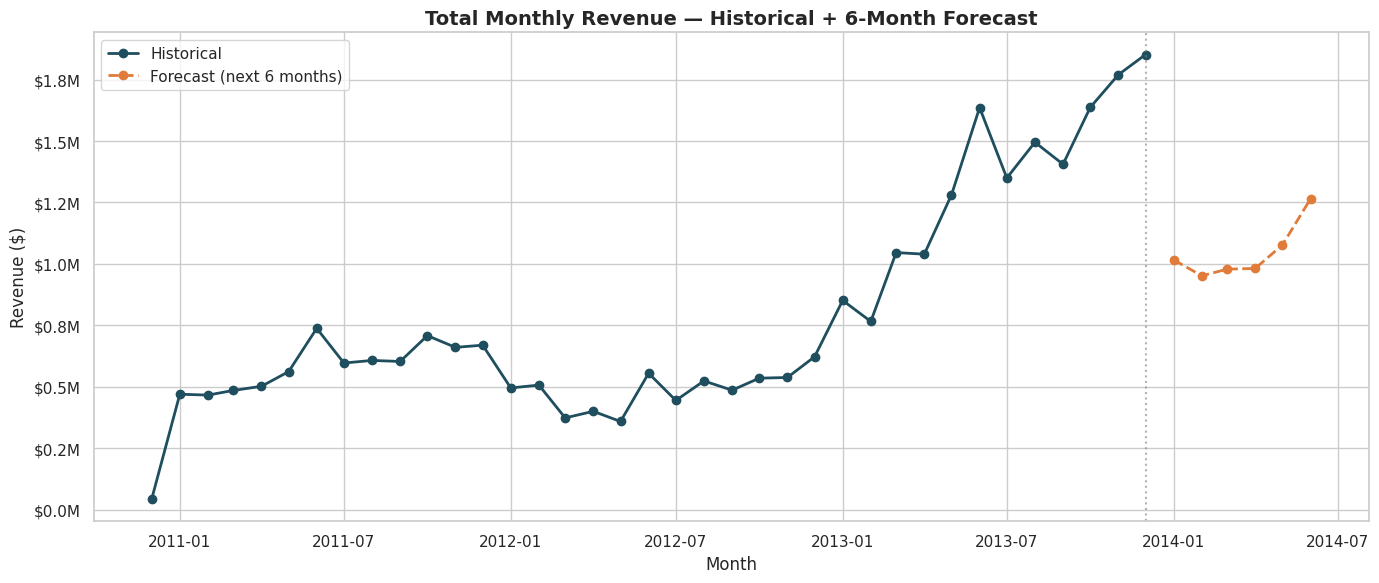

In [15]:
# Aggregate forecast: total forward revenue by month
total_fwd = forecasts_df.groupby('month')['forecast'].sum().reset_index()
historical = monthly.groupby('month')['revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(historical['month'], historical['revenue'], 'o-', color='#1F4E5F',
        label='Historical', linewidth=2)
ax.plot(total_fwd['month'], total_fwd['forecast'], 'o--', color='#E07B39',
        label='Forecast (next 6 months)', linewidth=2)
ax.axvline(historical['month'].max(), color='gray', linestyle=':', alpha=0.6)
ax.set_title('Total Monthly Revenue — Historical + 6-Month Forecast', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()


## 7. Save Outputs

Two CSVs for downstream use:
- `data/predictions/forecasts.csv` — the forward forecast for each `product_line x country x month`, used by the prescriptive notebook
- `data/predictions/forecast_evaluation.csv` — the backtest metrics, useful for future model comparison


In [16]:
forecasts_df.to_csv(PRED_DIR / 'forecasts.csv', index=False)
print(f'Saved: {PRED_DIR / "forecasts.csv"} ({len(forecasts_df)} rows)')

results_df.to_csv(PRED_DIR / 'forecast_evaluation.csv', index=False)
print(f'Saved: {PRED_DIR / "forecast_evaluation.csv"} ({len(results_df)} rows)')


Saved: ../data/predictions/forecasts.csv (72 rows)
Saved: ../data/predictions/forecast_evaluation.csv (36 rows)


## 8. Conclusions

### Headline Finding: Naive Baseline Beats Prophet

| Model | Median MAPE | Wins (of 12 series) |
|---|---|---|
| **Naive** (last value) | **~27%** | **7 / 12** |
| Prophet | ~39% | 4 / 12 |
| Seasonal Naive (-12) | ~56% | 1 / 12 |

The naive baseline — just carrying forward the last observed value — outperforms Prophet on more than half the series, and has a substantially better median MAPE. This is the honest finding from this experiment.

### Why Did Prophet Lose?

Three factors, in roughly decreasing importance:

1. **Insufficient seasonal cycles.** Prophet's strongest feature is yearly seasonality detection, which needs 2-3+ years of clean data. We have just under 3 years total, and only ~2.5 years of training history per series after holding out the 6-month test window. That's the lower edge of where Prophet works.

2. **High volatility at the product_line x country level.** Splitting 60K transactions across 12 series leaves each series with relatively few transactions per month, especially in smaller markets. Month-to-month random variation dominates the signal.

3. **2013 was a real growth period.** Many series show roughly 2-3x growth from 2012 to 2013. Prophet correctly identifies the growth trend, but the magnitude of growth is hard to project. The naive "last value" benefits when growth is monotonic and recent.

Look at the standout: **Mountain x Australia** — Prophet hit 4% MAPE while Naive was 76%. When the seasonality is strong and clean, Prophet works beautifully. The other series just don't have that property.

### What We Built Anyway

Even though Prophet isn't the winner, the **pipeline** is the deliverable. This notebook demonstrates:

- Walk-forward backtesting (no data leakage)
- Multiple baselines, not just one model
- Three complementary metrics (MAPE, MAE, RMSE), each with their own caveats
- Series filtering by minimum history
- Honest reporting when the sophisticated model loses

A real analyst's report says "the naive baseline is competitive at this scale; do not invest in Prophet productionization without more data first." That's the take here.

### Forward Forecasts

The `forecasts.csv` file contains Prophet's 6-month forward projections. These are usable for the prescriptive notebook (`05_prescriptive.ipynb`) where forecast magnitude matters less than relative ordering between regions and product lines. Even when Prophet's point estimates are inaccurate, its relative comparisons (which product_line x country combinations are expected to grow most?) tend to be informative.

### Limitations to Flag

1. **Series dropped:** half the original 24 series had insufficient history. Low-volume regions and the Touring product line cannot be forecasted at this granularity.
2. **No exogenous variables.** Holidays, promotions, marketing spend — none of these were available. With them, Prophet would likely improve substantially.
3. **Single split, not rolling window.** A more rigorous evaluation would use multiple walk-forward windows. For 30 training months and a 6-month test, single split is what we have.
4. **Wide confidence intervals.** The 80% intervals on the forward forecast reflect genuine uncertainty; do not treat point estimates as commitments.

### Next Steps

- **`04_forecasting_lstm.ipynb`** — Build a PyTorch LSTM. **Expected outcome:** it will likely struggle to beat both Prophet and the naive baseline at this data volume. We report that result honestly. The notebook becomes a *demonstration of the technique* and an *honest comparison*, not a victory lap.
- **`05_prescriptive.ipynb`** — Combine these forecasts with segments from notebook 02 to produce action lists for marketing, inventory, and customer service.